# Bayesian Linear Regression

In this lab we will see how you can use ${\tt pymc}$ to implement a simple Bayesian Linear Regression model. For the purposes of this lab you are given a data set with house prices and their size (in sq. feet).

In [1]:
import pandas as pd

data = pd.read_csv("data/house_data.csv")

In the following we create a list/vector for the independent variable $x$ (sq. feet of the home), and one for the dependent variable $y$ (price in $1000s). We also center the independent variable, which helps with interpretation (and when there are multiple variables with multicolinearity and interaction terms).

We then define our Bayesian Linear Regression model, assigning a normal prior with zero mean and a variance of 100 (sigma) both for the intercept (beta0) and the slope (beta1). These can be considered as uninformative priors, since they do not indicate any positive or negative correlation (but rather an expected correlation of 0), while also having a high uncertainty (i.e., high variance). We also set the prior for the variance of the model to a Half Cauchy (that is guaranteed to always be positive).

Next we define variable $mu$ as the linear combination of the intercept and the mean-centered size of the house. The final step is to define the dependent variable $y$, which is a normally distributed random variable with mean equal to $mu$ and a standard deviation of $sigma$.

We now are ready to call the ${\tt sample()}$ function that will sample from the posterior of beta0, beta1 and $sigma$.

In [2]:
import pymc as pm
import numpy as np
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

x = data["size_sqft"].values
y = data["price_k"].values
x_mean = np.mean(x)
x_centered = x - x_mean

# Bayesian linear regression
with pm.Model() as bayes_model:
    beta0 = pm.Normal("beta0", mu=0, sigma=100)
    beta1 = pm.Normal("beta1", mu=0, sigma=100)
    sigma = pm.HalfCauchy("sigma", beta=10)

    mu = beta0 + beta1 * x_centered
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)

    trace = pm.sample(1000, tune=1000, target_accept=0.9, return_inferencedata=True)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 9 seconds.


We sampled 2 chains, with 2000 samples each and a 1000 samples of burn in. We can now plot a summary of the inference, as well as, the posterior distributions from each chain and the trace.

In [3]:
az.summary(trace, var_names=["beta0", "beta1", "sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,298.401,2.032,294.751,302.331,0.032,0.023,4015.0,2787.0,1.0
beta1,0.147,0.005,0.137,0.155,0.000,0.000,3674.0,2872.0,1.0
sigma,19.874,1.426,17.221,22.471,0.023,0.017,3958.0,2580.0,1.0


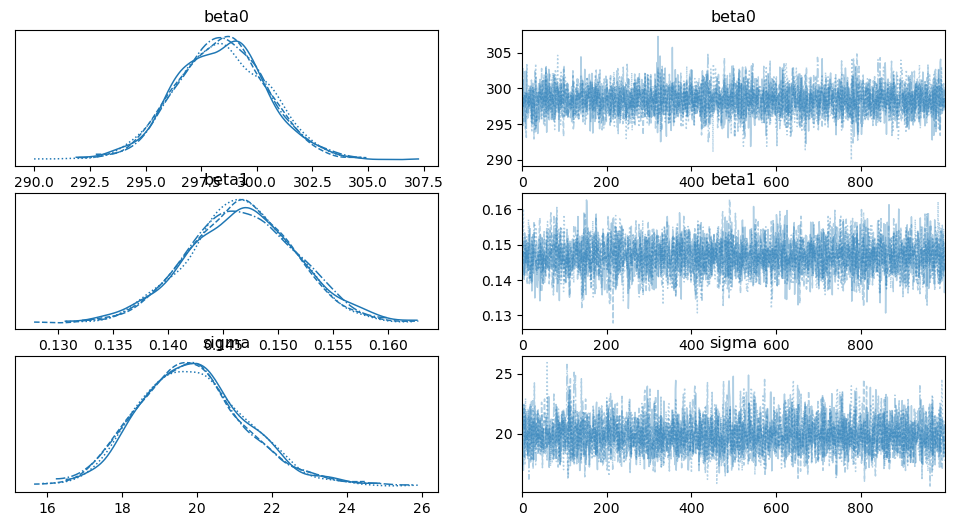

In [4]:

az.plot_trace(trace, var_names=["beta0", "beta1", "sigma"])
plt.show()

# Making Predictions

We can now make predictions for new data points by obtaining the posterior samples of each coefficient and computing the distribution for $mu$. We can then sample the normal random variable that corresponds to the dependent variable.

In [5]:
# Predictions
new_sizes = np.array([1000, 1500, 2000, 2500])
new_centered = new_sizes - x_mean

posterior = trace.posterior
beta0_samples = posterior["beta0"].stack(draws=("chain", "draw")).values
beta1_samples = posterior["beta1"].stack(draws=("chain", "draw")).values
sigma_samples = posterior["sigma"].stack(draws=("chain", "draw")).values

# Compute mu_* for each new data point
mu_preds = beta0_samples[:, None] + beta1_samples[:, None] * new_centered

# Sample from predictive distribution
y_preds = np.random.normal(loc=mu_preds, scale=sigma_samples[:, None])

# Summarize predictions
pred_df = pd.DataFrame({
    "size_sqft": new_sizes,
    "pred_mean": y_preds.mean(axis=0),
    "pred_90_low": np.percentile(y_preds, 5, axis=0),
    "pred_90_high": np.percentile(y_preds, 95, axis=0)
})

In [6]:
pred_df

,size_sqft,pred_mean,pred_90_low,pred_90_high
0,1000,202.701750,169.014837,234.972719
1,1500,276.559287,244.495721,308.508710
2,2000,349.094720,316.317780,382.619066
3,2500,422.624467,389.159472,455.863770


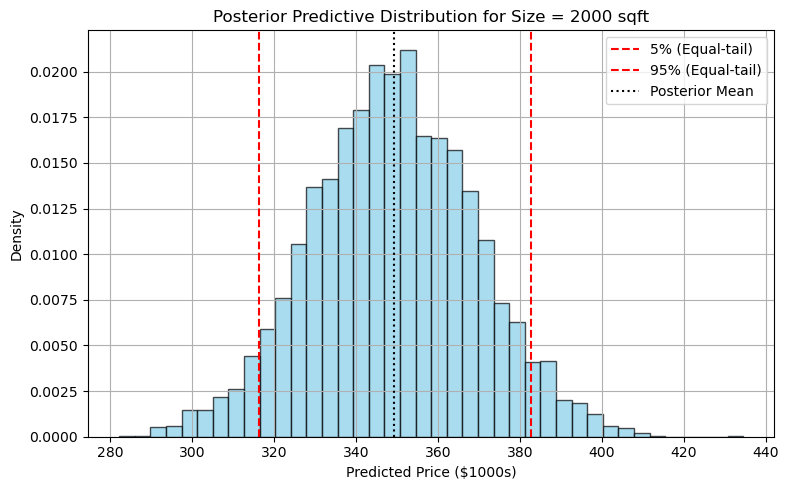

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# y_preds: shape (n_samples, n_new_points)
# Let's choose the prediction for 2000 sqft (index 2)
index = 2
y_dist = y_preds[:, index]

plt.figure(figsize=(8, 5))
plt.hist(y_dist, bins=40, density=True, alpha=0.7, color="skyblue", edgecolor="k")
plt.axvline(np.percentile(y_dist, 5), color="red", linestyle="--", label="5% (Equal-tail)")
plt.axvline(np.percentile(y_dist, 95), color="red", linestyle="--", label="95% (Equal-tail)")
plt.axvline(np.mean(y_dist), color="black", linestyle=":", label="Posterior Mean")
plt.title("Posterior Predictive Distribution for Size = 2000 sqft")
plt.xlabel("Predicted Price ($1000s)")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ordinary least squares

Next we run the frequentist linear regression to compare the coefficient obtained. To reiterate, in OLS the coefficients are assumed to be fixed but unknown and are associated with a standard error.  

In [8]:
# OLS model
X = sm.add_constant(x_centered)
ols_model = sm.OLS(y, X).fit()
ols_summary = ols_model.summary()

print(ols_summary)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.906
Method:                 Least Squares   F-statistic:                     960.3
Date:                Wed, 26 Aug 2026   Prob (F-statistic):           1.95e-52
Time:                        05:17:12   Log-Likelihood:                -439.28
No. Observations:                 100   AIC:                             882.6
Df Residuals:                      98   BIC:                             887.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        298.5652      1.977    151.053      0.0

As we can see the OLS coefficients match pretty well with the posterior mean from the Bayesian linear regression. This means that (i) the data are informative, and, thus the Bayesian posterior is dominated by the likelihood, or, (ii) the priors used for the Bayesian linear regression are non-informative. Of course, both also can be true.

# Sensitivity to the prior

Next we are going to examine the sensitivity of the Bayesian linear regression to the coefficient priors. This will not be a systematic comparison of course but we are going to explore a strong prior (as an extreme case) in order to observe the differences.

In [9]:
# Prior sensitivity
with pm.Model() as sens_model:
    beta0_s = pm.Normal("beta0", mu=0, sigma=10)
    beta1_s = pm.Normal("beta1", mu=0, sigma=10)
    sigma_s = pm.HalfCauchy("sigma", beta=5)

    mu_s = beta0_s + beta1_s * x_centered
    y_obs_s = pm.Normal("y_obs", mu=mu_s, sigma=sigma_s, observed=y)

    trace_strong = pm.sample(1000, tune=1000, return_inferencedata=True)

az.summary(trace_strong, var_names=["beta0", "beta1", "sigma"])

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta0, beta1, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 8 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,38.118,10.851,16.818,57.716,0.201,0.144,2907.0,2843.0,1.0
beta1,0.148,0.063,0.028,0.266,0.001,0.001,3942.0,3137.0,1.0
sigma,263.278,21.598,223.264,304.314,0.407,0.288,2812.0,2432.0,1.0


What we observe is that the posterior mean for beta0 is much closer to 0 this time. The reason for this is that we started from a strong prior belief that beta0 is centered around 0 (with a much smaller variance) and either we do not have enough data points for the likelihood to dominate such a strong prior, or, that the data are not informative.

The tighter prior pulls the posterior means towards 0 - partibularly beta0, which is the intrecept of the centered regression. This is a form of shrinkage.